# GPU Runtime: Regression Ensembles

## Project Overview

This notebook applies tree-based regression ensembles to predict GPU operation running time from parameter settings.

The target is constructed as the mean of the final four runtime measurements in each row. The experiments compare a mean predictor, a single regression tree, a manually averaged randomized-tree ensemble, Random Forests, Extra Trees, gradient boosting, and histogram-based gradient boosting.

### Technical Coverage

- dataset distribution inspection
- target construction from repeated runtime measurements
- mean-prediction baseline
- DecisionTreeRegressor
- randomized regression trees
- prediction averaging
- ensemble-size MSE analysis
- RandomForestRegressor
- ExtraTreesRegressor
- GradientBoostingRegressor
- HistGradientBoostingRegressor

## 1. Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.model_selection import train_test_split
import tensorflow as tf


In [5]:
from google.colab import drive
import os

drive.mount("/content/drive")

os.chdir(
    "/content/drive/MyDrive/Machine Learning/8. Ensembles of Models/notebooks"
)

print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/Machine Learning/8. Ensembles of Models/notebooks


## 2. GPU Runtime Dataset

Place `gpu_running_time.csv` inside the project `data/` directory. The notebook treats every column except the final four as input features and averages the final four columns to form the regression target.

In [6]:
data_path = Path("../data/gpu_running_time_sgemm_product.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "Place gpu_running_time_sgemm_product.csv in the project data directory before running this notebook."
    )

df = pd.read_csv(data_path)
df


,MWG,NWG,KWG,MDIMC,NDIMC,MDIMA,NDIMB,KWI,VWM,VWN,STRM,STRN,SA,SB,Run1 (ms),Run2 (ms),Run3 (ms),Run4 (ms)
0,16,16,16,8,8,8,8,2,1,1,0,0,0,0,115.26,115.87,118.55,115.80
1,16,16,16,8,8,8,8,2,1,1,0,0,0,1,78.13,78.25,79.25,79.19
2,16,16,16,8,8,8,8,2,1,1,0,0,1,0,79.84,80.69,80.76,80.97
3,16,16,16,8,8,8,8,2,1,1,0,0,1,1,84.32,89.90,86.75,85.58
4,16,16,16,8,8,8,8,2,1,1,0,1,0,0,115.13,121.98,122.73,114.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241595,128,128,32,32,32,32,32,8,4,4,1,0,1,1,17.96,17.77,17.77,17.77
241596,128,128,32,32,32,32,32,8,4,4,1,1,0,0,36.04,36.03,36.04,36.03
241597,128,128,32,32,32,32,32,8,4,4,1,1,0,1,35.28,34.82,35.27,35.27
241598,128,128,32,32,32,32,32,8,4,4,1,1,1,0,28.43,28.49,28.44,28.45


### Feature and Runtime Distributions

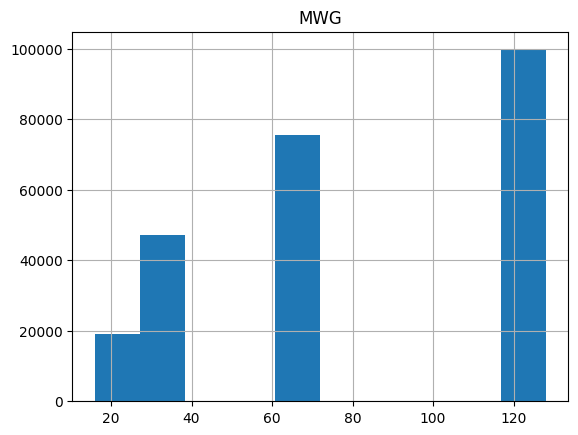

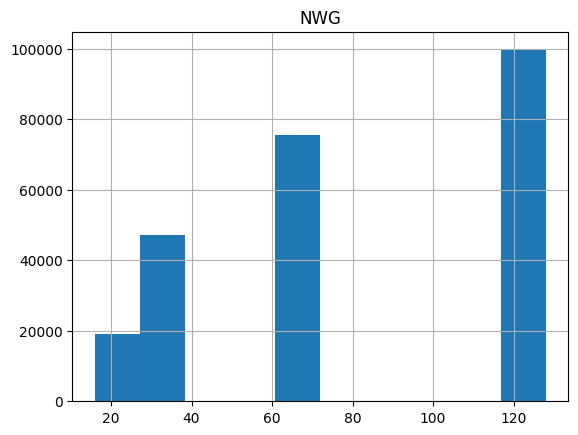

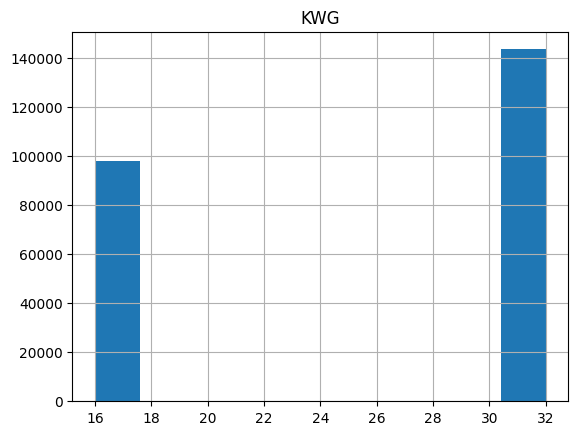

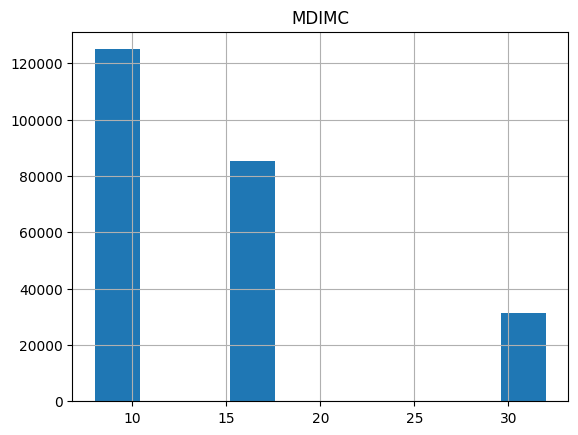

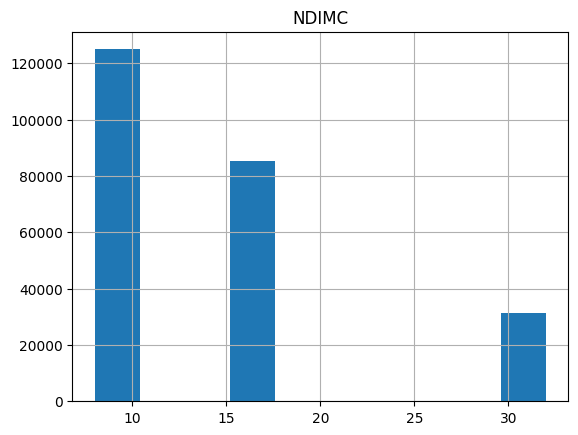

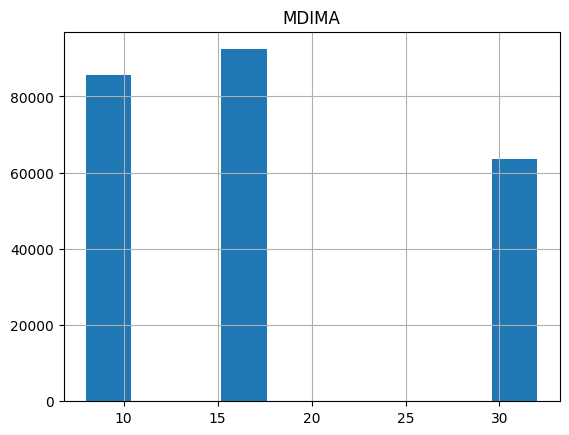

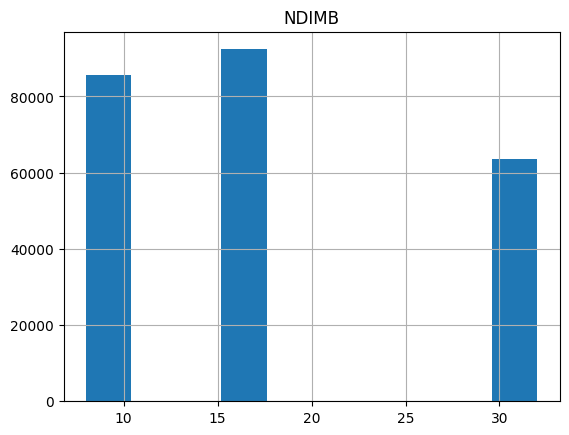

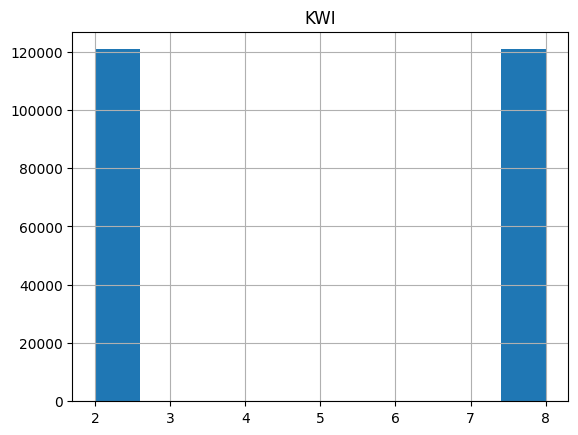

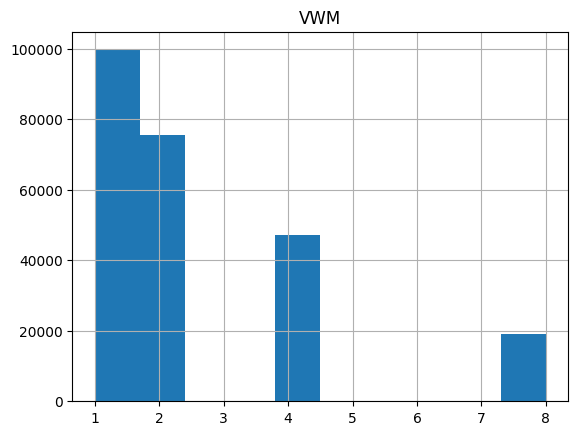

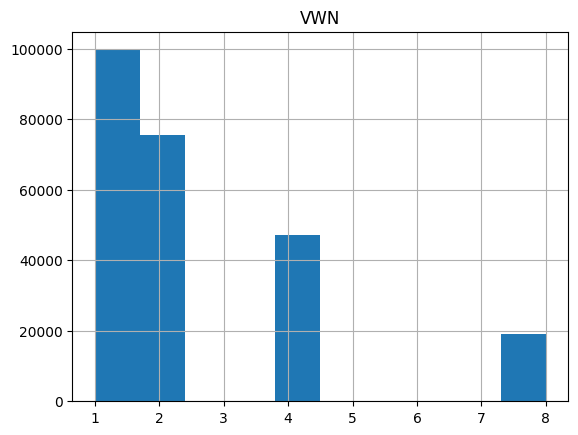

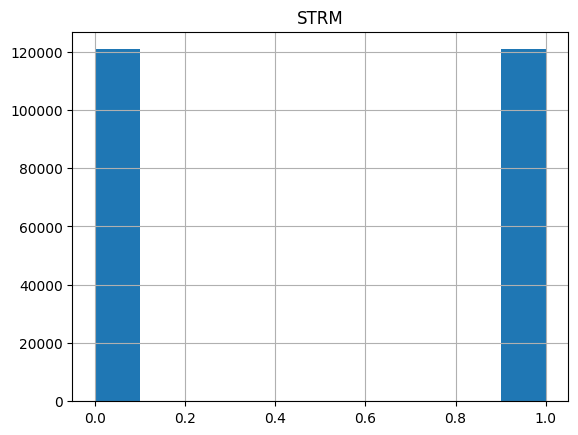

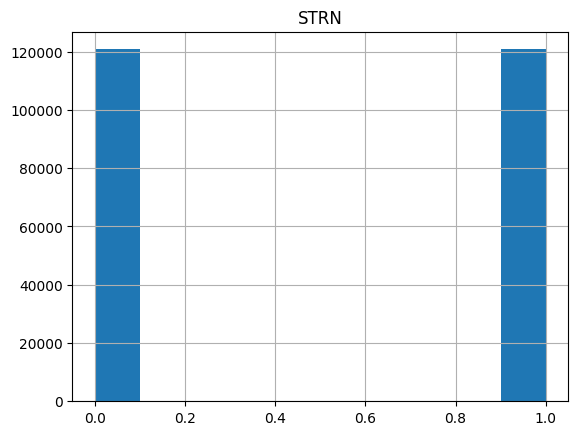

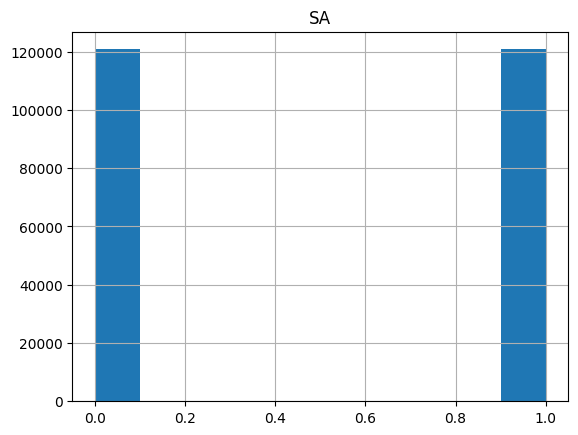

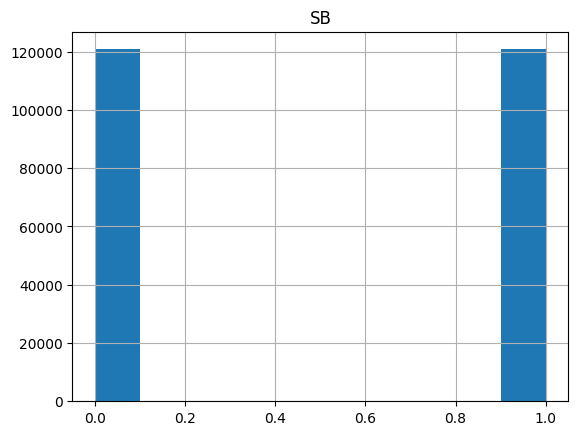

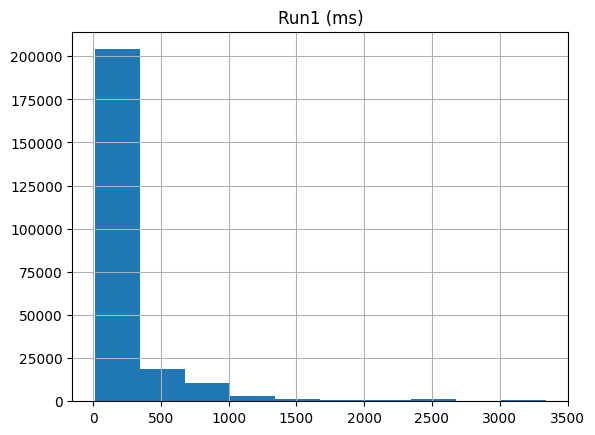

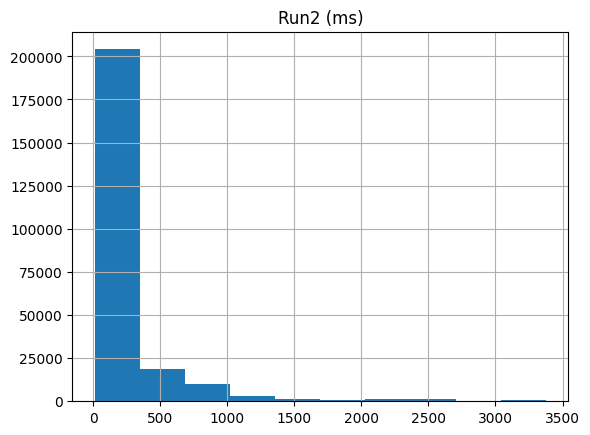

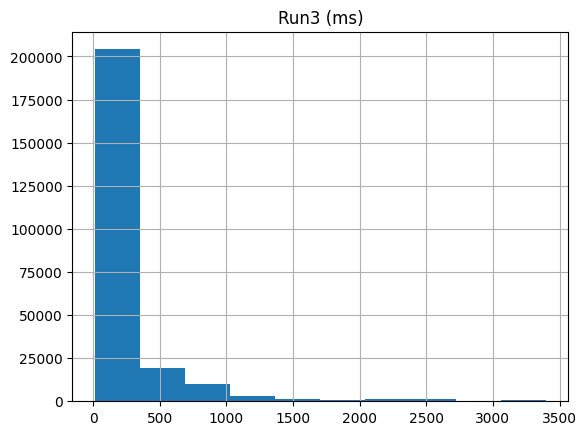

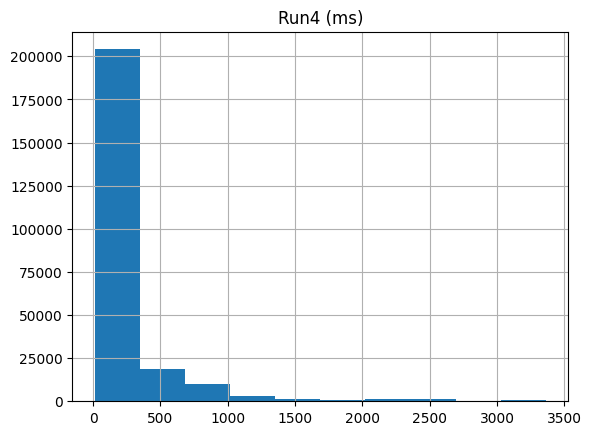

In [7]:
for c in df.columns:
  hist = df.hist(column=c, bins=10)

## 3. Feature Matrix and Regression Target

The input matrix contains all columns except the final four runtime measurements. The target is the row-wise mean of those four measurements. A 70/30 train/test split is used.

In [8]:
data = df.to_numpy()
X = data[:,:-4]
y = np.mean(data[:,-4:],axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=4361)

### First Target Value

In [9]:
y[0]


np.float64(116.37)

### First Complete Data Row

In [10]:
data[0]

array([ 16.  ,  16.  ,  16.  ,   8.  ,   8.  ,   8.  ,   8.  ,   2.  ,
         1.  ,   1.  ,   0.  ,   0.  ,   0.  ,   0.  , 115.26, 115.87,
       118.55, 115.8 ])

## 4. Mean-Prediction Baseline

Every test observation is assigned the mean training target. This provides a simple reference MSE and MAE.

In [11]:
pred = np.mean(y_train)+np.zeros_like(y_test)
print('Mean squared error = {:5.2f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.2f}'.format(mean_absolute_error(pred,y_test)))

Mean squared error = 136404.14
Mean absolute error =  217.08


## 5. Single Regression Tree

An unrestricted `DecisionTreeRegressor` provides the single-tree baseline.

In [12]:
model = DecisionTreeRegressor()
model.fit(X_train,y_train)
pred = model.predict(X_test)
print('Mean squared error = {:5.2f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:5.2f}'.format(mean_absolute_error(pred,y_test)))

Mean squared error = 25.43
Mean absolute error =   1.59


## 6. Manual Randomized-Tree Ensemble

One hundred regression trees use `splitter='random'`. The MSE of each individual tree and the MSE of the cumulative average prediction are tracked after every model.

In [13]:
model = DecisionTreeRegressor(splitter='random')
sum_pred = 0
model_mse, ens_mse = [], []
for i in range(100):
  model.fit(X_train,y_train)
  pred = model.predict(X_test)
  mse = mean_squared_error(pred,y_test)
  model_mse.append(mse)
  sum_pred += pred
  msee = mean_squared_error(sum_pred/(i+1),y_test)
  ens_mse.append(msee)
  print(f'Model {i:2} MSE {mse:.6} Ensemble MSE {msee:.6}')


Model  0 MSE 39.9674 Ensemble MSE 39.9674
Model  1 MSE 44.0465 Ensemble MSE 30.3521
Model  2 MSE 77.0988 Ensemble MSE 30.6973
Model  3 MSE 63.5814 Ensemble MSE 29.0352
Model  4 MSE 39.0912 Ensemble MSE 25.7081
Model  5 MSE 40.0028 Ensemble MSE 23.4162
Model  6 MSE 50.3059 Ensemble MSE 22.8973
Model  7 MSE 42.1765 Ensemble MSE 22.0538
Model  8 MSE 44.494 Ensemble MSE 21.7932
Model  9 MSE 48.5761 Ensemble MSE 21.785
Model 10 MSE 45.4464 Ensemble MSE 21.4878
Model 11 MSE 42.3808 Ensemble MSE 21.1735
Model 12 MSE 56.1341 Ensemble MSE 21.3009
Model 13 MSE 41.6479 Ensemble MSE 21.1182
Model 14 MSE 40.9382 Ensemble MSE 20.8651
Model 15 MSE 40.0608 Ensemble MSE 20.8225
Model 16 MSE 47.4223 Ensemble MSE 20.7987
Model 17 MSE 40.5838 Ensemble MSE 20.6559
Model 18 MSE 43.7477 Ensemble MSE 20.6141
Model 19 MSE 53.4357 Ensemble MSE 20.7471
Model 20 MSE 40.859 Ensemble MSE 20.6144
Model 21 MSE 39.7733 Ensemble MSE 20.4511
Model 22 MSE 42.8105 Ensemble MSE 20.3291
Model 23 MSE 50.6569 Ensemble MSE 20.

### MSE vs. Ensemble Size

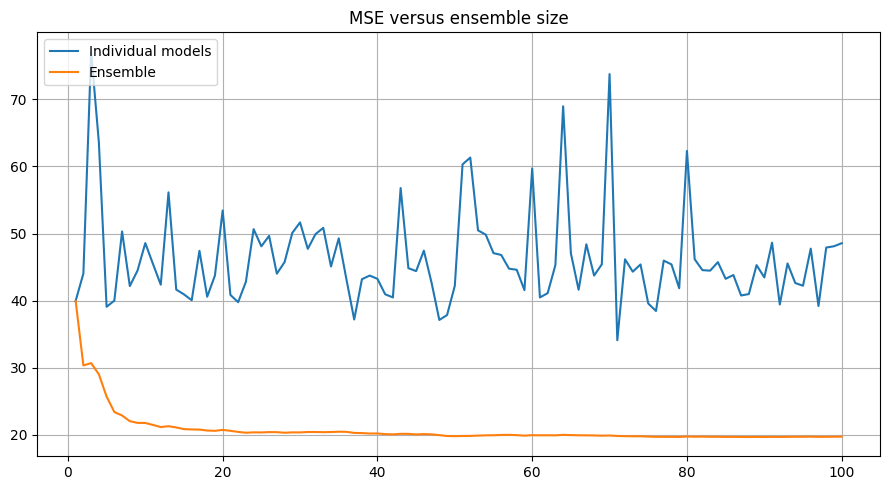

In [14]:
fig0, ax0 = plt.subplots(figsize=(9,5))
ax0.set_title('MSE versus ensemble size')
plt.grid(True)
ax0.plot(np.arange(1,len(model_mse)+1), model_mse,label = 'Individual models')
ax0.plot(np.arange(1,len(model_mse)+1), ens_mse,label = 'Ensemble')
ax0.legend(loc='upper left')
fig0.tight_layout()

## 7. Random Forest Regressor

Training and test MSE are reported separately.

In [15]:
model = RandomForestRegressor(n_jobs=-1)
model.fit(X_train,y_train)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)
print('Mean squared error training = {:7.5f}'.format(mean_squared_error(pred_train,y_train)))
print('Mean squared error test set = {:7.5f}'.format(mean_squared_error(pred_test,y_test)))

Mean squared error training = 2.58249
Mean squared error test set = 19.36255


## 8. Extra Trees Regressor

The same train/test MSE comparison is repeated with extremely randomized regression trees.

In [16]:
model = ExtraTreesRegressor(n_jobs=-1)
model.fit(X_train,y_train)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)
print('Mean squared error training = {:7.5f}'.format(mean_squared_error(pred_train,y_train)))
print('Mean squared error test set = {:7.5f}'.format(mean_squared_error(pred_test,y_test)))

Mean squared error training = 0.00000
Mean squared error test set = 19.92604


## 9. Gradient Boosting Regressor

Gradient boosting constructs the regression ensemble sequentially.

In [17]:
model = GradientBoostingRegressor(verbose=2)
model.fit(X_train,y_train)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)
print('Mean squared error training = {:7.5f}'.format(mean_squared_error(pred_train,y_train)))
print('Mean squared error test set = {:7.5f}'.format(mean_squared_error(pred_test,y_test)))


      Iter       Train Loss   Remaining Time 
         1      125972.6270           13.57s
         2      117553.7474           12.90s
         3      110568.0804           12.56s
         4      104399.2853           12.40s
         5       98027.4937           12.09s
         6       92384.9143           12.24s
         7       88076.2822           11.99s
         8       83584.1158           11.83s
         9       79527.6913           11.62s
        10       76353.8843           11.42s
        11       73044.7930           11.25s
        12       70447.6272           11.08s
        13       67812.1517           10.92s
        14       65385.8392           10.85s
        15       63351.2023           10.74s
        16       61615.1899           10.62s
        17       59855.4558           10.47s
        18       58403.4847           10.32s
        19       56806.3314           10.17s
        20       55497.8947           10.02s
        21       54287.2515            9.87s
        2

## 10. Histogram Gradient Boosting Regressor

The final model uses histogram-based gradient boosting.

In [18]:
model = HistGradientBoostingRegressor(verbose=2)
model.fit(X_train,y_train)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)
print('Mean squared error training = {:7.5f}'.format(mean_squared_error(pred_train,y_train)))
print('Mean squared error test set = {:7.5f}'.format(mean_squared_error(pred_test,y_test)))

Binning 0.017 GB of training data: 0.077 s
Binning 0.002 GB of validation data: 0.006 s
Fitting gradient boosted rounds:
[1/100] 1 tree, 31 leaves, max depth = 9, train loss: 55804.76774, val loss: 56442.55272, in 0.023s
[2/100] 1 tree, 31 leaves, max depth = 9, train loss: 46079.66986, val loss: 46545.70161, in 0.023s
[3/100] 1 tree, 31 leaves, max depth = 8, train loss: 38197.45403, val loss: 38555.30872, in 0.022s
[4/100] 1 tree, 31 leaves, max depth = 8, train loss: 31790.64985, val loss: 32015.58982, in 0.022s
[5/100] 1 tree, 31 leaves, max depth = 9, train loss: 26597.12140, val loss: 26757.09678, in 0.020s
[6/100] 1 tree, 31 leaves, max depth = 8, train loss: 22362.56752, val loss: 22464.63217, in 0.021s
[7/100] 1 tree, 31 leaves, max depth = 8, train loss: 18898.85820, val loss: 18929.20016, in 0.022s
[8/100] 1 tree, 31 leaves, max depth = 9, train loss: 16084.74317, val loss: 16088.07016, in 0.021s
[9/100] 1 tree, 31 leaves, max depth = 8, train loss: 13742.57589, val loss: 13

## 11. Evaluation Framework

The regression experiments report:

- mean squared error for the constant-mean baseline
- mean absolute error for the constant-mean baseline
- MSE and MAE for a single decision tree
- individual-tree and cumulative-ensemble MSE across 100 randomized trees
- training and test MSE for the four library ensemble regressors

The ensemble-size curve directly shows whether prediction averaging stabilizes and improves the randomized regression trees.

## 12. Key Takeaways

- Averaging randomized regression-tree predictions provides a direct demonstration of variance reduction.
- Random Forests and Extra Trees provide packaged randomized-tree ensembles.
- Gradient boosting and histogram gradient boosting use sequential error correction rather than independent tree averaging.
- Comparing training and test MSE helps distinguish fit quality from generalization performance.